In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

custom_map = [
    "FSFF",
    "FFFH",
    "FFGF",
    "HFFF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=False
)

n_states = env.observation_space.n
n_actions = env.action_space.n

START_STATE = 1
GOAL_STATE = 10


In [11]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [13]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        return env.action_space.sample()

    return np.argmax(Q[state])



In [14]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Start from our custom start state
    env.unwrapped.s = START_STATE
    state = START_STATE

    action = epsilon_greedy_action(
        state,
        epsilon
    )

    total_reward = 0

    for step in range(max_steps_per_episode):

        next_state, reward, terminated, truncated, info = env.step(action)

        # Check if custom goal was reached
        if next_state == GOAL_STATE:
            reward = 1.0
            terminated = True

        total_reward += reward

        # SARSA update for terminal state
        if terminated or truncated:

            Q[state, action] += alpha * (
                reward - Q[state, action]
            )

            break

        # Choose next action
        next_action = epsilon_greedy_action(
            next_state,
            epsilon
        )

        # SARSA update
        Q[state, action] += alpha * (
            reward
            + gamma * Q[next_state, next_action]
            - Q[state, action]
        )

        state = next_state
        action = next_action

    episode_rewards.append(total_reward)

    # Reduce exploration
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# -------------------------------------------------
# State Values and Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)




In [15]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [16]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.861 0.875 0.968 0.859]
 [0.957 0.978 0.957 0.965]
 [0.966 0.877 0.614 0.831]
 [0.815 0.    0.468 0.397]
 [0.902 0.811 0.976 0.846]
 [0.967 0.99  0.98  0.965]
 [0.906 1.    0.    0.831]
 [0.    0.    0.    0.   ]
 [0.874 0.    0.983 0.866]
 [0.976 0.964 1.    0.975]
 [0.    0.    0.    0.   ]
 [0.19  0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.816 0.811 0.99 ]
 [0.138 0.168 0.079 0.985]
 [0.209 0.001 0.001 0.008]]

Estimated State-Value Function:
[[0.968 0.978 0.966 0.815]
 [0.976 0.99  1.    0.   ]
 [0.983 1.    0.    0.19 ]
 [0.    0.99  0.985 0.209]]

Learned Policy:
[['R' 'D' 'L' 'L']
 ['R' 'D' 'D' 'L']
 ['R' 'R' 'L' 'L']
 ['L' 'U' 'U' 'L']]

Average reward over last 1000 episodes: 1.0


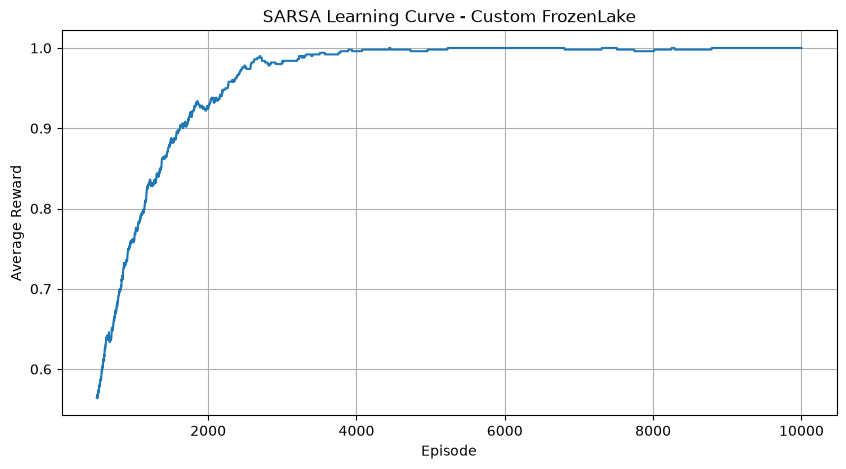

In [17]:
# ---------window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(window - 1, num_episodes),
    moving_average
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "SARSA Learning Curve - Custom FrozenLake"
)

plt.grid(True)

plt.show()

env.close()